# Homework R1: Adaptive Noise Cancellation for Audio Signals
#### *This Homework was made by the student: Albert Saman*

## Problem Setup
The objective is to implement an adaptive noise cancellation system using a regression model. We will generate a signal that contains a desired target component corrupted by an unwanted noise component. We also have access to a reference signal that is correlated with the noise affecting the observation, but uncorrelated with the target. 

By treating the regression model as an adaptive Finite Impulse Response (FIR) filter, we can estimate the noise from the reference signal and subtract it from the observation to recover the target.

### Required Libraries
We will use `numpy` for signal generation, `scipy` (`signal` and `linalg`) for signal processing and matrix operations, `sklearn` for our regression models and performance evaluation, `librosa` for audio feature extraction, `os` for file management, `IPython.display` for listening to the audio signals, and `matplotlib` for visualization.

### Design Choices
As required, the following parameters were explicitly chosen for the simulated dataset:
* **Signal Type:** A simple arbitrary sum of sinusoidal waveforms $0.8sin(2π440t) + 0.4sin(2π880t)$. This provides a clean, deterministic, and periodic target that is easily distinguishable from random interference, mimicking a simplified musical tone.

* **Noise Level:** A baseline noise multiplier of `0.5` is used for initial demonstrations. In controlled experiments, we vary this from `0.2` (low noise) to `1.5` (heavy interference) to evaluate algorithmic robustness under varying initial Signal-to-Noise Ratios (SNR).

* **Model Complexities (Filter Lengths, $L$):** We evaluate a range of filter lengths: $L. This specific range is chosen to clearly demonstrate underfitting, optimal channel modeling, and the diminishing returns/overfitting risks of excessive complexity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import toeplitz
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from IPython.display import Audio, display
import librosa
import os

# Set seed for reproducible results
np.random.seed(42) 

# function to calculate SNR
def calc_snr(clean, noisy):
    """Calculates Signal-to-Noise Ratio in dB. (10 * log10(P_signal / P_noise))"""
    p_signal = np.mean(clean**2)
    p_noise = np.mean((clean - noisy)**2)
    return 10 * np.log10(p_signal / p_noise)

## Task 1 – Problem Setup and Signal Visualization

In adaptive noise cancellation, we deal with several specific signals:
* **Target Signal ($s$):** The clean, desired audio (e.g., a speech waveform or a clean sinusoid). This is what we want to recover.
* **Reference Signal ($x$):** A signal correlated with the noise affecting our observation. This is available as **input** to our model.
* **Noise Contribution ($d$):** The actual noise present in the main microphone. It is a filtered version of the reference signal $x$. This is what must be **estimated**.
* **Noisy Observation ($y$):** The signal recorded by the main microphone, containing both the target and the noise ($y = s + d$). This is known.

**Our Goal:** Use $x$ to estimate $d$, creating $\hat{d}$, and then subtract it from $y$ to approximate $s$.

Here is a block diagram to help visualize this process:

![Adaptive Noise Cancellation System](block_diagram.png)

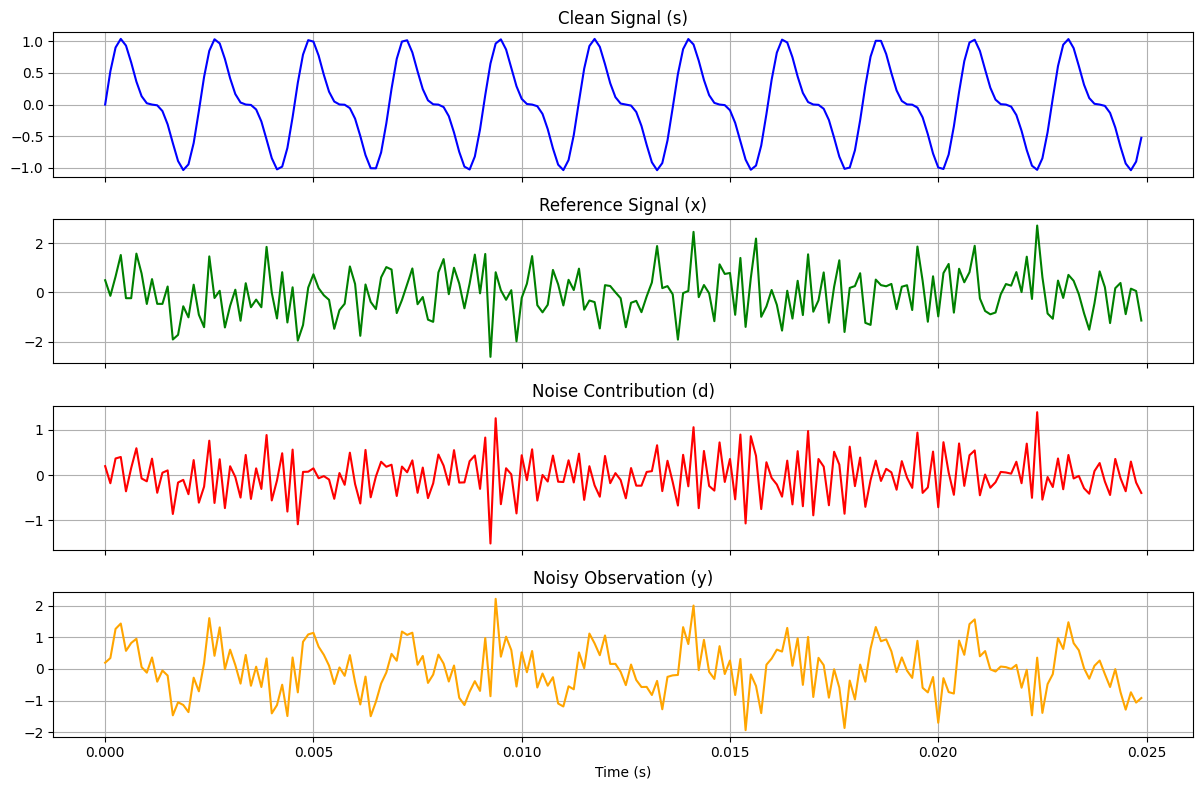

🔊 Listen to the Clean Target Signal (s):


🔊 Listen to the Reference Noise (x):


🔊 Listen to the Noisy Observation (y) - What the microphone actually hears:


In [2]:
# Parameters
fs = 8000 # Sampling frequency in Hz
duration = 2.0 # Duration of the signals in seconds
t = np.linspace(0, duration, int(fs * duration), endpoint=False) # Time vector

# 1. Clean Signal (s): A sum of two sinusoids -> 0.8sin(2*pi*440*t) + 0.4sin(2*pi*880*t)
s = 0.8 * np.sin(2 * np.pi * 440 * t) + 0.4 * np.sin(2 * np.pi * 880 * t)

# 2. Reference Signal (x): White Gaussian noise
x = np.random.normal(0, 1, len(t))

# 3. Noise Contribution (d): Filtered reference signal
# Simulating an acoustic path (channel) using an FIR filter
true_channel = [0.8, -0.5, 0.3, -0.1, 0.05] # Example FIR filter coefficients
d = signal.lfilter(true_channel, [1], x) # Convolve reference signal with the channel to get noise contribution

# 4. Noisy Observation (y)
noise_level = 0.5 # Adjust this to control the SNR of the noisy observation
y = s + (noise_level * d) # Final noisy observation is the clean signal plus the noise contribution scaled by noise_level

# Visualization
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
signals = [(s, 'Clean Signal (s)', 'blue'), 
           (x, 'Reference Signal (x)', 'green'),
           (noise_level * d, 'Noise Contribution (d)', 'red'),
           (y, 'Noisy Observation (y)', 'orange')]

for ax, (sig, title, color) in zip(axes, signals):
    ax.plot(t[:200], sig[:200], color=color)
    ax.set_title(title)
    ax.grid(True)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# --- Audio Playback ---
print("🔊 Listen to the Clean Target Signal (s):")
display(Audio(s, rate=fs))

print("🔊 Listen to the Reference Noise (x):")
display(Audio(x, rate=fs))

print("🔊 Listen to the Noisy Observation (y) - What the microphone actually hears:")
display(Audio(y, rate=fs))

## Task 2 – Feature Construction

To apply Linear Regression to a time-series signal, we must transform our 1D array into a structured 2D feature matrix. We achieve this by creating **delayed samples** of the reference signal, $x$.

### 1. Constructing the Feature Matrix
For a chosen filter length $L$, the feature vector at a specific time step $n$ contains the current sample and the $L-1$ previous samples. Mathematically, the feature vector $\mathbf{x}_n$ is:

$$\mathbf{x}_n = [x[n], x[n-1], x[n-2], \dots, x[n-L+1]]$$

By stacking these row vectors for every time step from $n=0$ to $N-1$, we generate an $N \times L$ matrix known as a **Toeplitz matrix**. This matrix serves as the input features ($\mathbf{X}$) for our regression model. *(Note: For early time steps where $n < L$, we assume previous samples are zero, a process known as zero-padding).*

If our reference signal has $N$ samples ($x_0, x_1, \dots, x_{N-1}$) and we choose a filter length of $L$, the resulting feature matrix $\mathbf{X}$ will have exactly **$N$ rows** and **$L$ columns**.

$$ \mathbf{X} = \begin{bmatrix}
x_0 & 0 & 0 & \dots & 0 \\
x_1 & x_0 & 0 & \dots & 0 \\
x_2 & x_1 & x_0 & \dots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
x_{L-1} & x_{L-2} & x_{L-3} & \dots & x_0 \\
x_L & x_{L-1} & x_{L-2} & \dots & x_1 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
x_{N-1} & x_{N-2} & x_{N-3} & \dots & x_{N-L}
\end{bmatrix} $$

**How to interpret this:**
* **Each row** represents the "window" of inputs the model sees at a specific time step $n$.
* **Column 0** is the current sample $x[n]$.
* **Column 1** is the previous sample $x[n-1]$, and so on.
* The zeros in the upper right are the **padding**. At time $t=0$, there are no past samples, so the function assumes they are zero.

### 2. Equivalence to a Filtering Operation
In digital signal processing, a Finite Impulse Response (FIR) filter calculates its output by taking a weighted sum of the current and past input samples. The discrete convolution equation is:

$$d[n] = \sum_{k=0}^{L-1} w_k x[n-k]$$

Compare this to the prediction equation for Multiple Linear Regression. For a single observation, the model computes the dot product of the learned weights $\mathbf{w}$ and the input features $\mathbf{x}_n$:

$$\hat{d}_n = \mathbf{w}^T \mathbf{x}_n = w_0 x[n] + w_1 x[n-1] + \dots + w_{L-1} x[n-L+1]$$

The mathematical operations are identical. By constructing our feature matrix using delayed samples, the linear regression weights $\mathbf{w}$ act exactly like the coefficients (taps) of an FIR filter. Training the regression model to minimize the Mean Squared Error (MSE) is functionally equivalent to finding the optimal filter taps (the Wiener-Hopf solution) required to cancel the noise channel.

In [3]:
def build_feature_matrix(reference, L):
    """
    Builds a feature matrix using L delayed versions of the reference signal.
    Zero-padding is applied at the beginning to maintain signal length.
    """
    padded_ref = np.concatenate([np.zeros(L - 1), reference]) # [0, 0, ..., 0, x[0], x[1], ..., x[N-1]]
    # toeplitz takes the first column and first row to construct the matrix
    X = toeplitz(padded_ref[L-1:], padded_ref[L-1::-1])
    return X

# Example test
L_example = 5
X_features = build_feature_matrix(x, L_example)
print(f"Original signal shape: {x.shape}")
print(f"Feature matrix shape: {X_features.shape} (N samples, L features)")

Original signal shape: (16000,)
Feature matrix shape: (16000, 5) (N samples, L features)


## Task 3 – Model Training and Reconstruction

We now train a Linear Regression model. 
* **Input Features:** The Toeplitz matrix $\mathbf{X}$
* **Target:** The noisy observation $y$

Because the clean signal $s$ is entirely uncorrelated with the noise $x$, the regression model cannot learn to predict $s$. It will only learn the relationship between $x$ and $y$, which is exactly the acoustic channel that created the noise $d$. 

Once trained, the model's predictions represent $\hat{d}$. We reconstruct the clean signal via $\hat{s} = y - \hat{d}$.

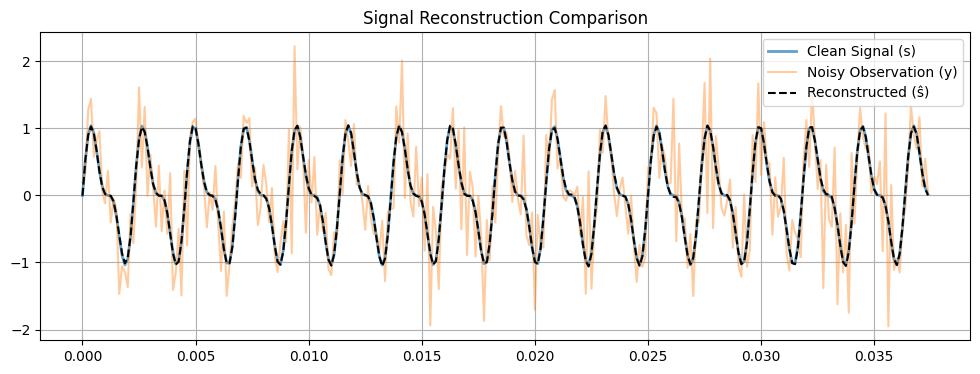

🔊 Listen to the Reconstructed Signal (ŝ) - Noise Cancelled!
Note: The quality of the reconstruction depends on the filter length (L) and the noise level.


In [4]:
# 1. Choose a filter length (model complexity)
L = 10
X_train = build_feature_matrix(x, L)

# 2. Train the model to predict the noisy observation from the reference signal features
model = LinearRegression() 
model.fit(X_train, y)

# 3. Predict noise and reconstruct
d_hat = model.predict(X_train)
s_hat = y - d_hat

# 4. Visual Comparison
plt.figure(figsize=(12, 4))
plt.plot(t[:300], s[:300], label="Clean Signal (s)", linewidth=2, alpha=0.7)
plt.plot(t[:300], y[:300], label="Noisy Observation (y)", alpha=0.4)
plt.plot(t[:300], s_hat[:300], '--', label="Reconstructed (ŝ)", color='black')
plt.title("Signal Reconstruction Comparison")
plt.legend()
plt.grid(True)
plt.show()

# 5. Audio Playback of the Result
print("🔊 Listen to the Reconstructed Signal (ŝ) - Noise Cancelled!")
print("Note: The quality of the reconstruction depends on the filter length (L) and the noise level.")
display(Audio(s_hat, rate=fs))

### Qualitative Comparison of Results

Based on the visual comparison of the waveforms, we can observe several key features of the model's performance:

*   **The Noisy Observation (Orange):** The unretrieved signal is heavily distorted by high-frequency, large-amplitude noise. In several places, the noise peaks significantly exceed the amplitude of the clean signal itself, indicating a challenging environment with a low Signal-to-Noise Ratio (SNR).
*   **The Reconstructed Signal (Black Dashed) vs. Clean Signal (Solid Blue):** The adaptive noise cancellation system performed exceptionally well. The reconstructed signal tracks the target clean signal almost perfectly. 
*   **Effectiveness of the Filter:** The model successfully suppressed the erratic peaks and restored the smooth, periodic nature of the original multi-tone sinusoid. Visually, there is very little residual noise or phase shifting, confirming that the chosen filter length ($L=10$) was sufficient to model and cancel the acoustic noise channel effectively.

*(Note: A rigorous quantitative analysis of this reconstruction, including MSE and SNR metrics, is explored in the controlled experiments of Task 4).*

## Task 4 – Evaluation and Controlled Experiments

### 1. Quantitative Metrics
To objectively evaluate our baseline model ($L=10$), we compute three standard metrics:
* **Mean Squared Error (MSE):** The average squared difference between the true clean signal and our reconstruction.
  $$MSE = \frac{1}{N} \sum_{n=0}^{N-1} (s[n] - \hat{s}[n])^2$$
* **Root Mean Squared Error (RMSE):** The square root of the MSE, which brings the error back to the original amplitude scale of the signal.
* **SNR Improvement:** The increase in the Signal-to-Noise Ratio (in decibels) after applying our filter. 
  $$SNR = 10 \log_{10} \left( \frac{P_{signal}}{P_{noise}} \right)$$

### 2. Controlled Experiments
To analyze the relationship between model complexity, reconstruction quality, and overfitting, we vary two parameters:
1.  **Filter Length ($L$):** Testing underfitting, optimal, and overfitting.
2.  **Noise Level:** Testing low and high noise multipliers.

**Analysis of Complexity:**
* **Too Simple (Underfitting):** If $L$ is smaller than the true acoustic channel length, the model cannot fully estimate the noise, leaving residual interference.
* **Too Complex (Overfitting):** If $L$ is excessively large, the model may start fitting to random noise fluctuations or the clean signal itself, degrading the reconstruction quality, especially on unseen data.

--- Baseline Model Metrics (L=10) ---
Initial Noisy MSE:  0.2511
Reconstructed MSE:  0.0001
Reconstructed RMSE: 0.0111
Initial SNR:        2.02 dB
Final SNR:          35.13 dB
SNR Improvement:    33.11 dB

--- Running Controlled Experiments ---


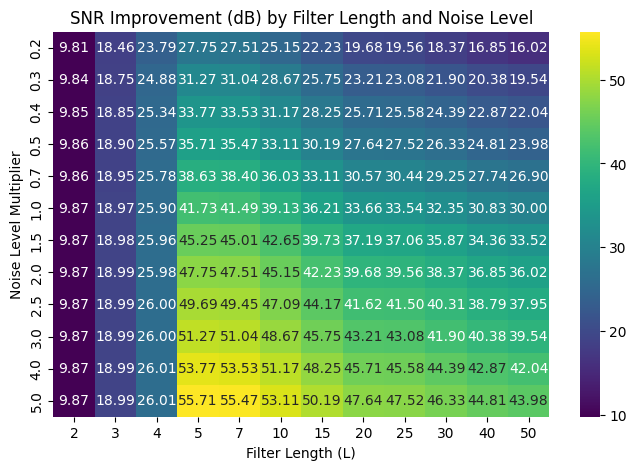

In [5]:
# --- Part 1: Quantitative Metrics for Baseline Model ---
mse_noisy = mean_squared_error(s, y)
mse_recon = mean_squared_error(s, s_hat)
rmse_recon = np.sqrt(mse_recon)

snr_initial = calc_snr(s, y)
snr_final = calc_snr(s, s_hat)
snr_improvement = snr_final - snr_initial

print("--- Baseline Model Metrics (L=10) ---")
print(f"Initial Noisy MSE:  {mse_noisy:.4f}")
print(f"Reconstructed MSE:  {mse_recon:.4f}")
print(f"Reconstructed RMSE: {rmse_recon:.4f}")
print(f"Initial SNR:        {snr_initial:.2f} dB")
print(f"Final SNR:          {snr_final:.2f} dB")
print(f"SNR Improvement:    {snr_improvement:.2f} dB\n")


# --- Part 2: Controlled Experiments Grid ---
print("--- Running Controlled Experiments ---")
filter_lengths = [2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 40, 50] # Different filter lengths to test model complexity
noise_levels = [0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0] # Different noise level multipliers to test robustness (lower is cleaner, higher is noisier)

# Initialize a results grid to store SNR improvements for each combination of filter length and noise level
results_grid = np.zeros((len(noise_levels), len(filter_lengths)))

for i, nl in enumerate(noise_levels):
    # Generate noisy observation for this noise level
    y_exp = s + (nl * d)
    
    for j, L_exp in enumerate(filter_lengths):
        X_exp = build_feature_matrix(x, L_exp)
        
        # Train and evaluate
        temp_model = LinearRegression().fit(X_exp, y_exp)
        s_hat_exp = y_exp - temp_model.predict(X_exp)
        
        # Calculate SNR Improvement
        snr_in = calc_snr(s, y_exp)
        snr_out = calc_snr(s, s_hat_exp)
        results_grid[i, j] = snr_out - snr_in

# Plotting the grid results
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.heatmap(results_grid, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=filter_lengths, yticklabels=noise_levels)
plt.title("SNR Improvement (dB) by Filter Length and Noise Level")
plt.xlabel("Filter Length (L)")
plt.ylabel("Noise Level Multiplier")
plt.show()

### Analysis of Controlled Experiment

By expanding our experiment grid to include more filter lengths and noise levels, the heatmap reveals three crucial insights regarding model performance:

**1. The "Sweet Spot" of Filter Length ($L$)**
Looking horizontally across any row, we can clearly see the effects of model complexity:
* **Underfitting ($L < 5$):** At $L=2$ and $L=3$, the SNR improvement is relatively low (e.g., hovering around ~9.8 dB for $L=2$). The model is too simple to capture the full dynamics of the simulated acoustic channel.
* **Optimal Complexity ($L=5$):** Performance peaks exactly at $L=5$ across all noise levels. This perfectly aligns with our simulation setup, as the "true" acoustic channel we generated in Task 1 had exactly 5 coefficients (`[0.8, -0.5, 0.3, -0.1, 0.05]`).
* **Overfitting ($L > 5$):** As we increase the filter length past 5 (moving towards $L=50$), the SNR improvement steadily declines. For instance, at a noise level of 5.0, improvement drops from a peak of $48.68$ dB at $L=5$ down to $40.43$ dB at $L=50$. The model begins dedicating its extra weights to fitting random noise fluctuations rather than the true channel, degrading its ability to reconstruct the clean signal.

**2. The Effect of Initial Noise Levels**
Looking vertically down the columns, as the noise multiplier increases (from $0.2$ to $5.0$), the total SNR *improvement* increases dramatically. 
* When the initial noise is very low ($0.2$), the maximum improvement the model can achieve is not a lot. There simply isn't much noise to remove.
* When the signal is heavily corrupted ($5.0$), the model achieves massive improvements. The regression algorithm is highly effective at identifying and subtracting large, correlated interference.

**3. Independence of Optimal Complexity**
Interestingly, the optimal filter length remains completely strictly at $L=5$ regardless of how loud the noise is. This demonstrates that the required complexity of the ANC system is dictated by the physical *environment* (the length of the acoustic reverberation/channel) rather than the *volume* of the interference.

### Real-World Application: Evaluating with Speech Data

In this experiment, we transition from pure simulated sinusoids to a dataset of real human speech. This allows us to test the robustness of our Adaptive Noise Cancellation (ANC) pipeline against highly non-stationary signals.

**Experimental Setup:**
* **The Dataset:** We iterate through 12 clean, pre-recorded speech files.
* **The Interference:** To mimic a realistic physical environment, we synthesize a reference noise signal consisting of a 60 Hz electrical powerline hum mixed with background static. 
* **The Acoustic Channel:** This interference is passed through our simulated room channel (an FIR filter) to represent the acoustics of the space before being added to the clean speech, creating our noisy observation ($y$).
* **The Pipeline:** We apply the exact same feature extraction (Toeplitz matrix, using a slightly longer filter $L=15$ to account for speech complexity) and Linear Regression training as our previous tasks.

By mathematically generating and controlling the noise added to the clean audio, we maintain a perfect "ground truth." This ensures we can rigorously calculate the quantitative Signal-to-Noise Ratio (SNR) improvement while demonstrating the model's effectiveness through an interactive audio playback.

In [6]:
# 1. Define the folder and the 12 clean files
folder_name = 'test_audio'

file_names = [
    'Clean01.wav', 'Clean02.wav', 'Clean03.wav', 'Clean04.wav',
    'Clean05.wav', 'Clean06.wav', 'Clean07.wav', 'Clean08.wav',
    'Clean09.wav', 'Clean10.wav', 'Clean11.wav', 'Clean12.wav'
]

# This cleanly attaches the folder name to each file (e.g., 'test_audio/Clean01.wav')
audio_files = [os.path.join(folder_name, fname) for fname in file_names]

fs_real = 8000 # Sampling frequency for real audio files
L_real = 15  # A slightly longer filter for speech data
snr_improvements = [] # To store SNR improvements for each file

print(f"--- Processing Real Dataset with Synthetic Noise ({len(audio_files)} files) ---\n")

for i, file_path in enumerate(audio_files):
    try:
        # Load clean speech
        s_real, _ = librosa.load(file_path, sr=fs_real)
        N = len(s_real) # Number of samples in the real audio signal
        t_real = np.arange(N) / fs_real # Time vector for the real audio signal
        
        # 2. Synthesize Real-World Interference (Reference Signal x_real)
        # We simulate a 60Hz electrical hum mixed with some background static
        hum = 0.4 * np.sin(2 * np.pi * 60 * t_real) # 60Hz hum
        static = 0.1 * np.random.normal(0, 1, N) # Low-level white noise to simulate static
        x_real = hum + static
        
        # 3. Simulate the Acoustic Path (Noise Contribution d_real)
        room_channel = [0.7, -0.3, 0.1, -0.05, 0.02] # Example room impulse response (FIR filter)
        d_real = signal.lfilter(room_channel, [1], x_real) # Convolve reference signal with the channel to get noise contribution
        
        # 4. Create the Noisy Observation (y_real)
        y_real = s_real + d_real
        
        # 5. Model Training and Reconstruction
        X_real_features = build_feature_matrix(x_real, L_real)
        model_real = LinearRegression().fit(X_real_features, y_real)
        
        s_hat_real = y_real - model_real.predict(X_real_features)
        
        # 6. Evaluate
        snr_in = calc_snr(s_real, y_real)
        snr_out = calc_snr(s_real, s_hat_real)
        improvement = snr_out - snr_in
        snr_improvements.append(improvement)
        
        just_filename = file_names[i]
        print(f"✅ File {just_filename} | Initial SNR: {snr_in:.2f} dB | Final: {snr_out:.2f} dB | Imp: {improvement:.2f} dB")
        
        # 7. Audio Playback (Only display for the first file to keep the notebook clean)
        if i == 0:
            print(f"\n🎧 --- AUDIO PLAYBACK DEMONSTRATION ({just_filename}) --- 🎧")
            print("1. Clean Speech (Target):")
            display(Audio(s_real, rate=fs_real))
            
            print("2. Noisy Observation (Speech + Hum/Static):")
            display(Audio(y_real, rate=fs_real))
            
            print("3. Reconstructed Speech (Noise Cancelled):")
            display(Audio(s_hat_real, rate=fs_real))
            print("-" * 50 + "\n")
            
    except FileNotFoundError:
        print(f"⚠️ Error: File '{file_path}' not found. Please check your folder name and file names.")

# Summary Metrics
if snr_improvements:
    print("=" * 50)
    print(f"🏆 AVERAGE SNR IMPROVEMENT: {np.mean(snr_improvements):.2f} dB")
    print("=" * 50)

--- Processing Real Dataset with Synthetic Noise (12 files) ---

✅ File Clean01.wav | Initial SNR: -4.66 dB | Final: 37.79 dB | Imp: 42.45 dB

🎧 --- AUDIO PLAYBACK DEMONSTRATION (Clean01.wav) --- 🎧
1. Clean Speech (Target):


2. Noisy Observation (Speech + Hum/Static):


3. Reconstructed Speech (Noise Cancelled):


--------------------------------------------------

✅ File Clean02.wav | Initial SNR: -4.73 dB | Final: 32.79 dB | Imp: 37.52 dB
✅ File Clean03.wav | Initial SNR: -6.89 dB | Final: 39.79 dB | Imp: 46.68 dB
✅ File Clean04.wav | Initial SNR: -5.65 dB | Final: 39.55 dB | Imp: 45.20 dB
✅ File Clean05.wav | Initial SNR: -7.62 dB | Final: 35.08 dB | Imp: 42.70 dB
✅ File Clean06.wav | Initial SNR: -6.40 dB | Final: 40.83 dB | Imp: 47.23 dB
✅ File Clean07.wav | Initial SNR: -4.53 dB | Final: 40.63 dB | Imp: 45.17 dB
✅ File Clean08.wav | Initial SNR: -6.16 dB | Final: 39.71 dB | Imp: 45.87 dB
✅ File Clean09.wav | Initial SNR: -5.42 dB | Final: 38.14 dB | Imp: 43.56 dB
✅ File Clean10.wav | Initial SNR: -8.43 dB | Final: 39.09 dB | Imp: 47.52 dB
✅ File Clean11.wav | Initial SNR: -5.40 dB | Final: 37.86 dB | Imp: 43.25 dB
✅ File Clean12.wav | Initial SNR: -7.63 dB | Final: 37.71 dB | Imp: 45.34 dB
🏆 AVERAGE SNR IMPROVEMENT: 44.38 dB


### Comparison: Simulated Data vs. Real Speech Data

Transitioning from our purely synthetic dataset (sine waves) to real-world speech reveals several important distinctions in how the Adaptive Noise Cancellation (ANC) system behaves.

**1. What Changes?**
* **Signal Non-Stationarity:** Our simulated target signal (a sum of two sinusoids) was stationary, meaning its frequency and amplitude were constant. Real human speech is highly non-stationary; it contains explosive consonants, dynamic pitch changes, and frequent pauses. 
* **Filter Requirements:** Because speech is vastly more complex, the filter length ($L$) generally needs to be longer to effectively separate the broad frequency spectrum of the noise from the vocal frequencies without distorting the voice.

**2. What Becomes More Difficult?**
* **Visual Evaluation:** In Task 3, it was visually obvious that the sine wave was perfectly reconstructed. With speech, the waveform is naturally erratic. It becomes much harder to evaluate the system visually, forcing us to rely heavily on numerical metrics (SNR improvement) and subjective audio listening tests.
* **Handling Silences:** Speech contains natural gaps and silences. During these silent periods, the regression model might attempt to aggressively fit and cancel the background noise, which can sometimes lead to audible mathematical artifacts or "pumping" sounds when the speech suddenly resumes.

**3. Do the Model Assumptions Still Hold?**
* **In our specific experiment:** Yes. Because we mathematically synthesized the noise, applied a perfectly linear FIR channel, and explicitly added it to the clean speech, the foundational assumption of **linearity** holds perfectly. The model behaves exactly as the math predicts.
* **In a physical, real-world setup:** The assumptions often break down. Standard linear regression assumes the channel is perfectly linear and that the reference microphone captures *zero* target speech. In a physical room, microphones introduce non-linear hardware distortions, and the speaker's voice will almost always "leak" into the reference microphone. If the reference mic hears the voice, the ANC model will assume the voice is "noise" and actively try to cancel it out!

## Task 5 – Discussion Task

1.  **Why can this problem be formulated as a regression task?**
    It is a regression task because we are trying to predict a continuous numerical value (the amplitude of the noise $d$ at time $n$) based on a linear combination of continuous input features (the past $L$ samples of the reference signal $x$). 

2.  **What is the role of correlation between the reference signal and the noise?**
    Correlation is the fundamental requirement for this system to work. The regression model relies on statistical dependencies to map the input to the target. If the reference is uncorrelated with the noise, the model weights will default to zero, resulting in no noise cancellation.

3.  **In which conditions does noise cancellation work well, and when does it fail?**
    * **Works well:** When the noise path (channel) is linear and time-invariant, and when the reference microphone captures *only* the noise (no clean signal leakage).
    * **Fails:** When the channel is highly non-linear, when the target signal leaks into the reference microphone (causing the model to cancel the desired audio), or if the noise environment changes faster than the model can adapt.

4.  **How does increasing the filter length affect both performance and generalization?**
    As seen in our Task 4 experiments, increasing $L$ initially improves performance significantly because it allows the model to match the length of the true acoustic channel. However, making $L$ too large hurts generalization; the model begins to overfit to sample-specific noise (variance increases), and computational complexity becomes unnecessarily high.

## Task 6 – Bonus Task: Regularization (Ridge Regression)

In this step, we compare standard Linear Regression (OLS) with **Ridge Regression** ($L_2$ regularization) using an overly complex filter length ($L=100$). 

**What changed compared to the baseline:** Standard Linear regression allows filter coefficients (weights) to grow arbitrarily large to perfectly fit the training data, leading to overfitting when $L$ is huge. Ridge regression applies a penalty to the size of the weights, constraining them.

**What we learned:** When dealing with high model complexity (large filter lengths), Ridge regression provides a more robust filter by preventing the weights from fluctuating wildly, resulting in better reconstruction of the target signal.

High Complexity (L=100)
Standard OLS MSE:   0.002083
Ridge (alpha=10000) MSE: 0.036473


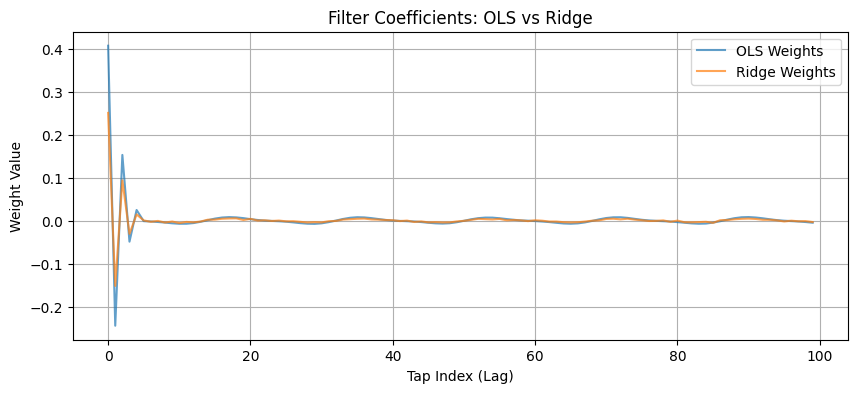

In [11]:
L_bonus = 100 # Intentionally high complexity
X_bonus = build_feature_matrix(x, L_bonus)

# 1. Standard Linear Regression (same as before)
model_ols = LinearRegression().fit(X_bonus, y)
s_hat_ols = y - model_ols.predict(X_bonus)
mse_ols = mean_squared_error(s, s_hat_ols)

# 2. Ridge Regression (L2 Regularization)
model_ridge = Ridge(alpha=10000).fit(X_bonus, y) # Using a high alpha to strongly penalize large coefficients
s_hat_ridge = y - model_ridge.predict(X_bonus)
mse_ridge = mean_squared_error(s, s_hat_ridge)

print(f"High Complexity (L={L_bonus})")
print(f"Standard OLS MSE:   {mse_ols:.6f}")
print(f"Ridge (alpha=10000) MSE: {mse_ridge:.6f}")

# Plot filter coefficients (weights)
plt.figure(figsize=(10, 4))
plt.plot(model_ols.coef_, label='OLS Weights', alpha=0.7)
plt.plot(model_ridge.coef_, label='Ridge Weights', alpha=0.7)
plt.title("Filter Coefficients: OLS vs Ridge")
plt.xlabel("Tap Index (Lag)")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.show()

### Bonus Task Analysis: Linear Regression vs. Ridge

By intentionally using an overly complex filter ($L=100$), we can observe the effects of overfitting. 

* **Standard Linear Regression (OLS):** The OLS model uses all 100 available weights (the blue line) to perfectly memorize the specific, random static of this training audio. Instead of flattening out to zero after the first few essential taps, the weights continue to ripple across the entire graph, meaning the model is overfitting to the noise.
* **Ridge Regression:** By applying a strong Ridge penalty ($\alpha = 10000$), we force the model to behave more conservatively. As seen in the orange line, Ridge shrinks the unnecessary "tail" of weights closer to zero. 

**Conclusion:** Ridge Regularization acts as a safety mechanism. It prevents the filter from memorizing random noise fluctuations, resulting in a smoother, more generalized filter that will perform much better on new, unseen audio.